In [39]:

import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os.path as op
from stress_risk.utils.data import add_cond2df
import pandas as pd

In [40]:
#df = pd.read_csv(op.join('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates','full_params_bambi1_NLC1.csv')) # risky task params only from session 1 for probir, mean 
df_probit_params = pd.read_csv('/Users/mrenke/data/ds-stressrisk/derivatives/cogmodels/param_estimates/bambi-1_subseswise_params.csv')
df_decod_acc = pd.read_csv('~/data/ds-stressrisk/derivatives/decoding_accuracy_allSub_allSes.csv')
df_decod_sd = pd.read_csv('~/data/ds-stressrisk/derivatives/decoding_sd_allSub_allSes.csv')

df_decod = df_decod_acc.set_index(['subject','session']).join(df_decod_sd.set_index(['subject','session']))


In [41]:
# for analyse_results/utils.py
df_auc = pd.read_excel('/Users/mrenke/Desktop/StressRisk/2022-StressRisk/Data-Final/auc_cortisol.xlsx')
df_auc = df_auc.rename(columns={'SubjectID':'subject'}).set_index('subject')[['AUC']] # double brackets --> dataframe
df_auc = df_auc[['AUC']].groupby('subject').mean()


In [ ]:
df = df_probit_params.set_index(['subject','session']).join(df_decod.set_index(['subject','session']))


In [19]:
df = add_cond2df(df)
df

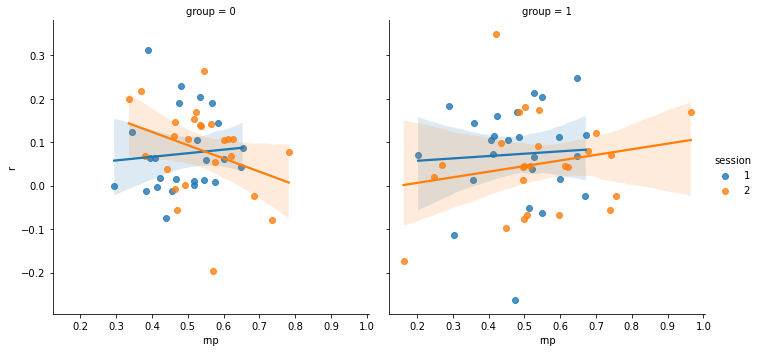

In [21]:
from scipy import stats
y = 'r'
x = 'rnp'
c = np.round(stats.pearsonr(df[x],df[y]), 3)

sns.lmplot(x=x, y=y, data = df.reset_index(), hue='session', col='group')
#plt.title(f'corr: r = {c[0]}, p = {c[1]}')


In [70]:
df_decod = add_cond2df(df_decod)

(array([1., 0., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 0.,
        0., 2., 0., 3., 0., 1., 2., 0., 0., 1., 0., 3., 0., 1., 1., 2., 4.,
        3., 0., 4., 3., 4., 0., 0., 0., 2., 1., 0., 1., 2., 1., 3., 0., 1.,
        1., 0., 4., 1., 3., 1., 1., 2., 0., 4., 2., 3., 3., 2., 0., 1., 2.,
        1., 1., 0., 0., 1., 4., 0., 0., 0., 0., 2., 1., 0., 1., 2., 0., 0.,
        1., 2., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 1.]),
 array([0.00142219, 0.00146533, 0.00150848, 0.00155163, 0.00159478,
        0.00163793, 0.00168107, 0.00172422, 0.00176737, 0.00181052,
        0.00185366, 0.00189681, 0.00193996, 0.00198311, 0.00202626,
        0.0020694 , 0.00211255, 0.0021557 , 0.00219885, 0.002242  ,
        0.00228514, 0.00232829, 0.00237144, 0.00241459, 0.00245774,
        0.00250088, 0.00254403, 0.00258718, 0.00263033, 0.00267348,
        0.00271662, 0.00275977, 0.00280292, 0.00284607, 0.00288921,
        0.00293236, 0.00297551, 0.00301866, 0.00306181, 0.00310495,
      

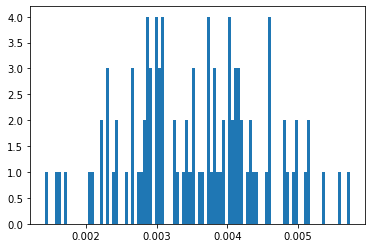

In [79]:
plt.hist(df_decod['sd'], bins=100)

In [72]:
df_decod.groupby(['session', 'group']).apply(lambda d: pingouin.ttest(d['sd'], 0.0))

T  dof alternative         p-val       CI95%  \
session group                                                                
1       0     T-test  20.279197   24   two-sided  1.307309e-16  [0.0, 0.0]   
        1     T-test  19.810416   24   two-sided  2.222968e-16  [0.0, 0.0]   
2       0     T-test  18.692618   24   two-sided  8.257426e-16  [0.0, 0.0]   
        1     T-test  16.984304   24   two-sided  7.049823e-15  [0.0, 0.0]   

                       cohen-d       BF10  power  
session group                                     
1       0     T-test  4.055839  3.757e+13    1.0  
        1     T-test  3.962083  2.264e+13    1.0  
2       0     T-test  3.738524  6.483e+12    1.0  
        1     T-test  3.396861  8.411e+11    1.0

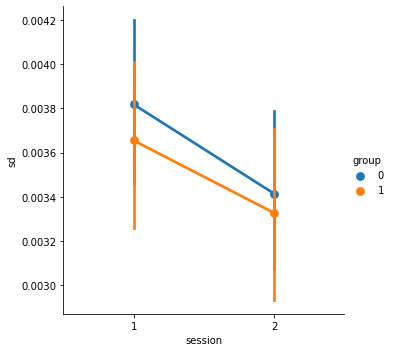

In [76]:
sns.catplot(data=df_decod.reset_index(), x='session', y='sd', hue='group', kind='point', errorbar='se')

In [27]:
df_ch_risky_prior = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_change_risky_prior.csv').set_index('subject')


In [28]:
from utils import get_stress_level
df_auc = get_stress_level()

In [49]:
from stress_risk.utils.data import get_data
df_comb = df_auc.join(df_ch_risky_prior)
df = get_data().set_index('group', append=True)
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)

df_comb =df_comb.join(group_mapping).set_index('group', append=True)

Text(23.830625000000012, 0.5, 'risky_prior_mu diff (ses2-ses1)')

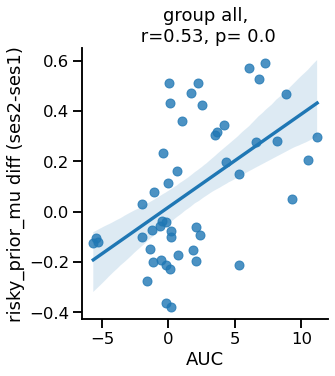

In [87]:
import pingouin
sns.set_context('talk')

group ='all' # 0, 1
temp = df_comb#.xs(group,0,'group')
sns.lmplot(x='AUC',y='risky_prior_mu', data=temp)
cor = pingouin.corr(temp['AUC'],temp['risky_prior_mu'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 2)
plt.title(f'group {group},\n r={r_}, p= {p}')
plt.ylabel('risky_prior_mu diff (ses2-ses1)')

In [90]:
df_motion = pd.read_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/subwise_seswise_motion.csv').set_index(['subject', 'session'])

In [92]:
df_motion.xs(2,0,'session')

,motion
subject,
1,0.189811
2,0.104101
3,0.225776
4,0.096983
5,0.098440
9,0.064618
10,0.092097
12,0.097426
13,0.125885


In [93]:
df_comb =df_comb.join(df_motion)

Text(0.5, 1.0, 'group all,\n r=0.1, p= 0.31')

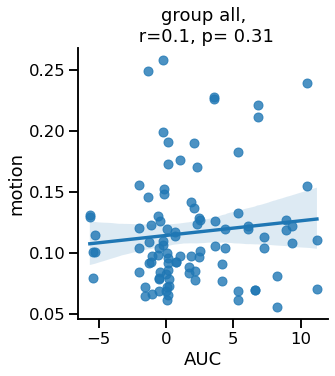

In [95]:
temp = df_comb#.xs(group,0,'group')
sns.lmplot(x='AUC',y='motion', data=temp)
cor = pingouin.corr(temp['AUC'],temp['motion'])
r_ = np.round(cor['r'][0], 2)
p = np.round(cor['p-val'][0], 2)
plt.title(f'group {group},\n r={r_}, p= {p}')